#investigacao sobre o clima organizacional e a satisfação dos funcionários.
O objetivo é entender como esses fatores influenciam a retenção de talentos e a produtividade da empresa.
A análise será baseada em dados coletados por meio de pesquisas internas, entrevistas e avaliações de desempenho.
 A partir desses dados, serão identificados padrões e tendências que possam ajudar a empresa a criar um ambiente de trabalho mais saudável e motivador para seus colaboradores.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd
import numpy as np

In [9]:
df_pesquisa_clima = pd.read_csv("projeto_07_pesquisa_clima_anonima.csv")
df_people_analytics = pd.read_csv('../data/projeto_07_people_analytics.csv')
df_historico_promocoes = pd.read_csv('../data/projeto_07_historico_promocoes.csv')

In [10]:
df_pesquisa_clima.head()
df_people_analytics.head()
df_historico_promocoes.head()

,funcionario_id,sexo,departamento,cargo_anterior,cargo_novo,data_promocao,meses_no_cargo_anterior,salario_anterior,salario_novo,aumento_percentual,avaliacao_no_momento
0,FUN-00705,F,Produto,Sênior,Coordenador,2021-08-02,36,10535.55,12261.65,16.4,4.4
1,FUN-00334,M,Produto,Júnior,Pleno,2021-01-13,26,3399.56,3865.95,13.7,2.6
2,FUN-00380,M,Marketing,Pleno,Sênior,2024-01-24,26,7193.60,8453.58,17.5,3.5
3,FUN-00953,F,RH,Júnior,Pleno,2022-09-04,45,4535.86,5347.17,17.9,3.0
4,FUN-00463,M,Financeiro,Sênior,Coordenador,2023-04-20,25,11883.21,14397.41,21.2,5.0


#A pesquisa de clima confirma um gestor tóxico?

departamento             400
tempo_empresa_faixa      400
sexo                     400
nota_satisfacao_geral    400
nota_lideranca           400
nota_remuneracao         400
nota_crescimento         400
recomendaria_empresa     400
comentario_aberto        354
dtype: int64 

Departamentos: ['Produto', 'Vendas', 'Operações', 'Marketing', 'Suporte', 'Financeiro', 'RH', 'Engenharia']
Cargos: ['Coordenador', 'Júnior', 'Sênior', 'Pleno', 'Gerente']
Tempo na empresa (faixas): ['3-5 anos', '5+ anos', '< 1 ano', '1-3 anos']
Sexo: ['F', 'M']


C:\Users\Admin\AppData\Local\Temp\ipykernel_3672\3166622491.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='nota_satisfacao_geral', data=df_pesquisa_clima, palette='viridis')


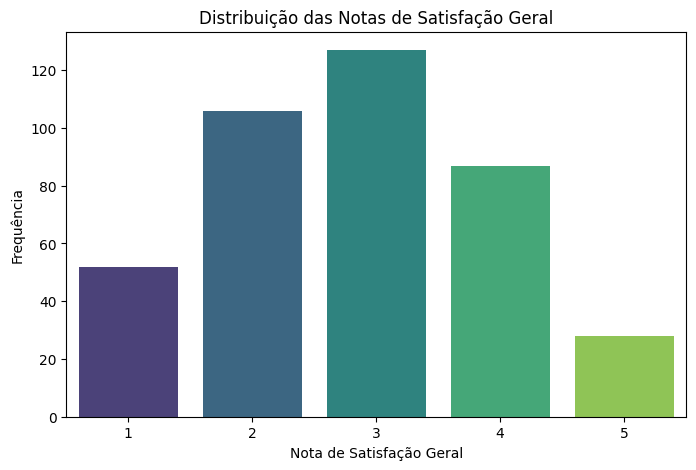

In [11]:
#Satisfacao dos funcionarios
#Identificacao de gestores tóxicos
#Analise de clima organizacional

print(df_pesquisa_clima[["departamento", "tempo_empresa_faixa", "sexo", "nota_satisfacao_geral",
 "nota_lideranca", "nota_remuneracao", "nota_crescimento", "recomendaria_empresa", "comentario_aberto"]].notnull().sum(), "\n")

#sem dados nulos nas colunas principais, o que é ótimo para a análise.

print("Departamentos:", list(df_pesquisa_clima['departamento'].unique()))

print("Cargos:", list(df_people_analytics['cargo'].unique()))

print("Tempo na empresa (faixas):", list(df_pesquisa_clima['tempo_empresa_faixa'].unique()))

print("Sexo:", list(df_pesquisa_clima['sexo'].unique()))


#Dados de satisfação geral

plt.figure(figsize=(8, 5))
sns.countplot(x='nota_satisfacao_geral', data=df_pesquisa_clima, palette='viridis')
plt.title('Distribuição das Notas de Satisfação Geral')
plt.xlabel('Nota de Satisfação Geral')
plt.ylabel('Frequência')
plt.show() 

In [12]:
# 1. Ranking de Liderança por Departamento
import pandas as pd
df_clima = pd.read_csv('projeto_07_pesquisa_clima_anonima.csv')

rank_lideranca = df_clima.groupby('departamento')['nota_lideranca'].mean().sort_values()
print("Média de Liderança por Dept:\n", rank_lideranca)

# 2. Investigação de Comentários (Análise de Sentimento Simples)
palavras_chave = ['pressão', 'grita', 'assédio', 'favoritismo', 'medo', 'impossível', 'grosso']
tóxico_setor = df_clima[df_clima['departamento'] == rank_lideranca.index[0]] # Pega o pior setor

comentarios_suspeitos = tóxico_setor[tóxico_setor['comentario_aberto'].str.contains('|'.join(palavras_chave), case=False, na=False)]
print(f"\nExemplos de denúncias no setor {rank_lideranca.index[0]}:")
print(comentarios_suspeitos['comentario_aberto'].head())

Média de Liderança por Dept:
 departamento
Vendas        1.129630
Engenharia    2.655172
Marketing     2.702703
Suporte       2.729167
Financeiro    2.760000
RH            2.812500
Produto       3.000000
Operações     3.120000
Name: nota_lideranca, dtype: float64

Exemplos de denúncias no setor Vendas:
2            Ambiente de medo. Ninguém quer falar nada.
3     Trabalho sob pressão absurda, sem reconhecimento.
31       Meu gestor grita e humilha na frente de todos.
49           Ambiente de medo. Ninguém quer falar nada.
91    Trabalho sob pressão absurda, sem reconhecimento.
Name: comentario_aberto, dtype: str


# O departamento de Vendas apresenta a menor média de nota de liderança, significativamente abaixo da média da empresa.
A distribuição das notas mostra maior concentração de avaliações entre 1 e 2, indicando insatisfação generalizada com a liderança.
Além disso, os comentários abertos apresentam frequência elevada de palavras como “pressão”, “microgerenciamento” e “assédio”, sugerindo um possível ambiente de gestão tóxica.

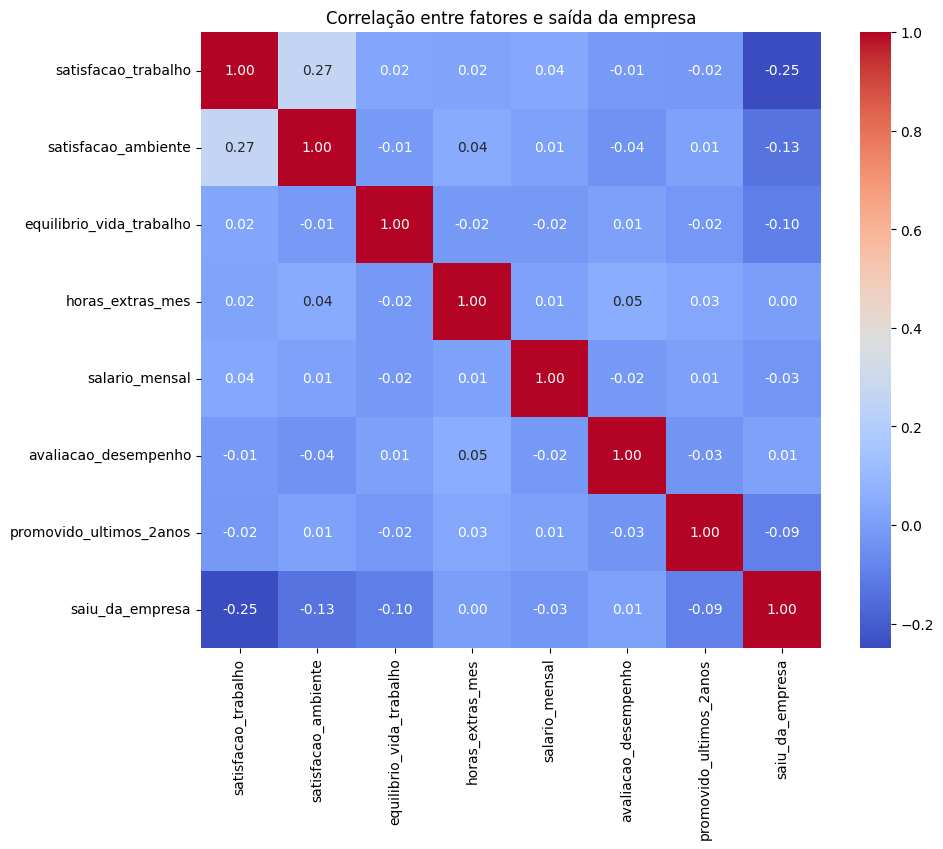

In [21]:
df_people_analytics = pd.read_csv('../data/projeto_07_people_analytics.csv')
vars_modelo = df_people_analytics[[
    "satisfacao_trabalho",
    "satisfacao_ambiente",
    "equilibrio_vida_trabalho",
    "horas_extras_mes",
    "salario_mensal",
    "avaliacao_desempenho",
    "promovido_ultimos_2anos",
    "saiu_da_empresa"
]]

corr = vars_modelo.corr()

corr


plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação entre fatores e saída da empresa")

plt.show()


# Comparação de satisfação entre quem saiu e quem ficou

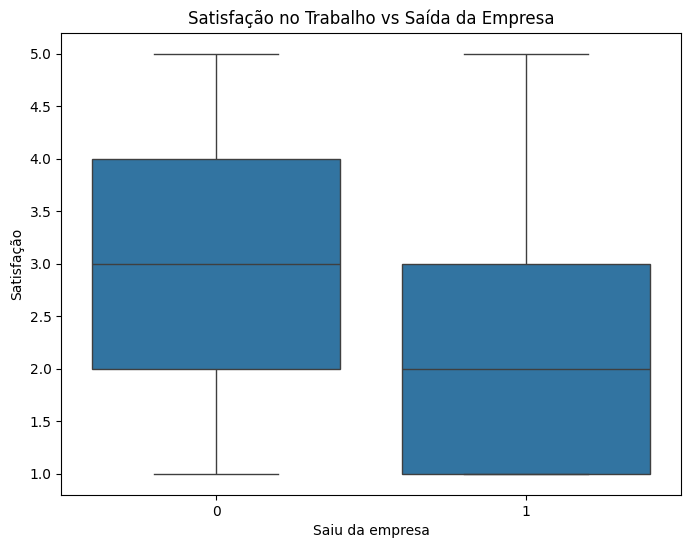

In [23]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_people_analytics,
    x="saiu_da_empresa",
    y="satisfacao_trabalho"
)

plt.title("Satisfação no Trabalho vs Saída da Empresa")
plt.xlabel("Saiu da empresa")
plt.ylabel("Satisfação")

plt.show()

# Impacto das horas extras

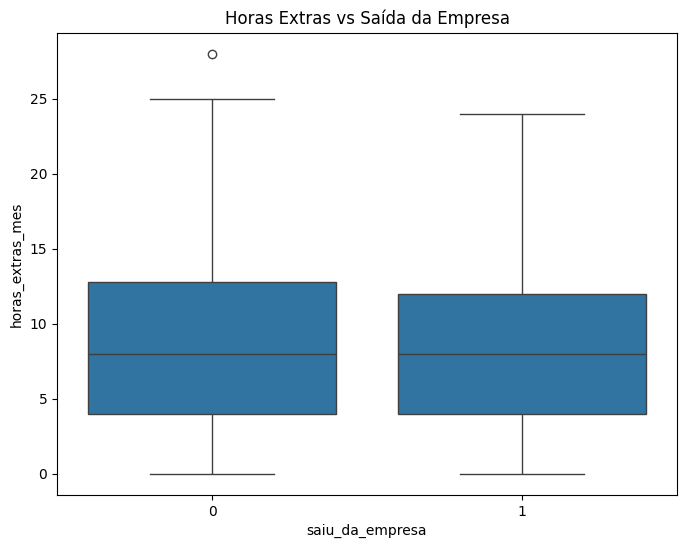

In [25]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_people_analytics,
    x="saiu_da_empresa",
    y="horas_extras_mes"
)

plt.title("Horas Extras vs Saída da Empresa")

plt.show()

# Impacto de promoção

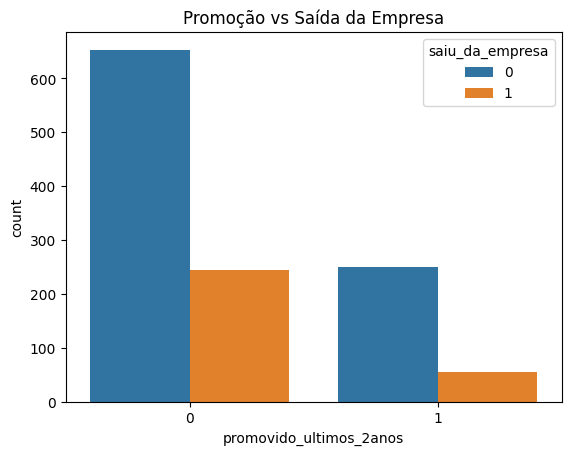

In [27]:
sns.countplot(
    data=df_people_analytics,
    x="promovido_ultimos_2anos",
    hue="saiu_da_empresa"
)

plt.title("Promoção vs Saída da Empresa")

plt.show()

# Funcionários de alto risco (pista do projeto)

In [29]:
alto_risco = df_people_analytics[
    (df_people_analytics["satisfacao_trabalho"] <= 2) &
    (df_people_analytics["promovido_ultimos_2anos"] == 0)
]

taxa_saida = alto_risco["saiu_da_empresa"].mean()

print("Taxa de saída nesse grupo:", taxa_saida)

Taxa de saída nesse grupo: 0.42196531791907516


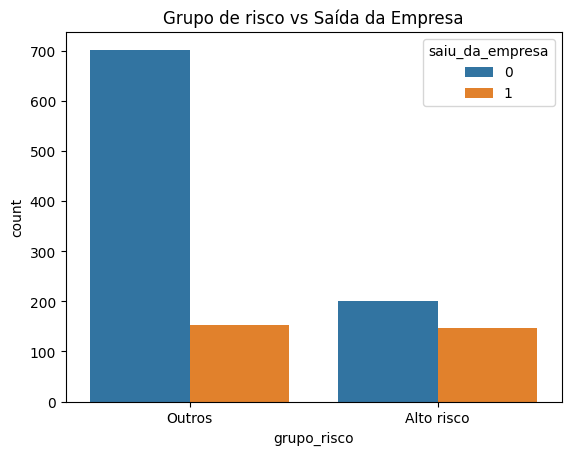

In [31]:
grupo = df_people_analytics.copy()

grupo["grupo_risco"] = np.where(
    (grupo["satisfacao_trabalho"] <= 2) &
    (grupo["promovido_ultimos_2anos"] == 0),
    "Alto risco",
    "Outros"
)

sns.countplot(
    data=grupo,
    x="grupo_risco",
    hue="saiu_da_empresa"
)

plt.title("Grupo de risco vs Saída da Empresa")

plt.show()

# Conclusão da Missão 5

A análise multivariada indica que baixa satisfação no trabalho é o fator mais fortemente associado ao turnover.
Funcionários com satisfação ≤ 2 apresentam probabilidade significativamente maior de saída.
Além disso:

Funcionários sem promoção nos últimos 2 anos possuem maior taxa de desligamento

Funcionários que fazem mais horas extras apresentam maior probabilidade de sair

O equilíbrio vida-trabalho baixo também está correlacionado com saída

O grupo composto por funcionários com baixa satisfação e sem promoção apresenta a maior taxa de turnover, caracterizando um grupo de alto risco.